In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Order_ID,Order_Date,Region,Category,Product,Quantity,Unit_Price,Sales,Profit
0,ORD-1001,2025-01-01,East,Office Supplies,Stapler,8,918.05,7344.40,653.69
1,ORD-1002,2025-01-01,East,Office Supplies,Printer Paper,8,533.88,4271.04,366.10
2,ORD-1003,2025-01-02,South,Furniture,Office Chair,2,18327.97,36655.94,10433.68
3,ORD-1004,2025-01-03,North,Clothing,Sneakers,5,3819.64,19098.20,3875.28
4,ORD-1005,2025-01-03,West,Clothing,T-Shirt,1,3291.22,3291.22,493.57


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 500
Number of Columns: 9


In [5]:
print("Column Names:")

print(df.columns.tolist())

Column Names:
['Order_ID', 'Order_Date', 'Region', 'Category', 'Product', 'Quantity', 'Unit_Price', 'Sales', 'Profit']


In [6]:
print("Data Types:")

print(df.dtypes)

Data Types:
Order_ID          str
Order_Date        str
Region            str
Category          str
Product           str
Quantity        int64
Unit_Price    float64
Sales         float64
Profit        float64
dtype: object


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    500 non-null    str    
 1   Order_Date  500 non-null    str    
 2   Region      500 non-null    str    
 3   Category    500 non-null    str    
 4   Product     500 non-null    str    
 5   Quantity    500 non-null    int64  
 6   Unit_Price  500 non-null    float64
 7   Sales       500 non-null    float64
 8   Profit      500 non-null    float64
dtypes: float64(3), int64(1), str(5)
memory usage: 35.3 KB


In [8]:
df.describe()

,Quantity,Unit_Price,Sales,Profit
count,500.000000,500.000000,500.00000,500.000000
mean,5.390000,12278.826460,63881.00668,10893.579480
std,2.908405,14958.236057,95914.05450,17885.328825
min,1.000000,63.750000,137.70000,9.830000
25%,3.000000,1318.552500,6889.83000,1008.095000
50%,5.000000,5252.760000,22589.52000,3591.875000
75%,8.000000,18771.977500,78233.30000,11473.790000
max,10.000000,59800.900000,551309.50000,119711.300000


**Meaningful Questions:**

1. Which product category generates the highest sales?
2. Which month has the highest sales?
3. Which products are the top sellers?
4. Is there a relationship between quantity sold and sales?
5. Are there any unusual sales values?
6. Are there missing values or duplicate records?

In [10]:
df.isnull().sum()

Order_ID      0
Order_Date    0
Region        0
Category      0
Product       0
Quantity      0
Unit_Price    0
Sales         0
Profit        0
dtype: int64

In [11]:
print("Number of duplicate rows:")

print(df.duplicated().sum())
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("Order_Date converted successfully!")

Number of duplicate rows:
0
Order_Date converted successfully!


In [12]:
df = df.drop_duplicates()

print("Duplicate rows removed!")
print("New dataset shape:", df.shape)
if "Discount" in df.columns:
    df["Discount"] = df["Discount"].fillna(df["Discount"].median())

if "Product" in df.columns:
    df["Product"] = df["Product"].fillna("Unknown Product")

print("Missing values handled!")

Duplicate rows removed!
New dataset shape: (500, 9)
Missing values handled!


In [13]:
print("Missing values after cleaning:")
print(df.isnull().sum())
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df.head()

Missing values after cleaning:
Order_ID      0
Order_Date    0
Region        0
Category      0
Product       0
Quantity      0
Unit_Price    0
Sales         0
Profit        0
dtype: int64


,Order_ID,Order_Date,Region,Category,Product,Quantity,Unit_Price,Sales,Profit,Month
0,ORD-1001,2025-01-01,East,Office Supplies,Stapler,8,918.05,7344.40,653.69,2025-01
1,ORD-1002,2025-01-01,East,Office Supplies,Printer Paper,8,533.88,4271.04,366.10,2025-01
2,ORD-1003,2025-01-02,South,Furniture,Office Chair,2,18327.97,36655.94,10433.68,2025-01
3,ORD-1004,2025-01-03,North,Clothing,Sneakers,5,3819.64,19098.20,3875.28,2025-01
4,ORD-1005,2025-01-03,West,Clothing,T-Shirt,1,3291.22,3291.22,493.57,2025-01


**TRENDS AND PATTERN ANALYSIS**

Category
Electronics        21149893.44
Furniture           8055823.71
Clothing            2270137.02
Office Supplies      464649.17
Name: Sales, dtype: float64


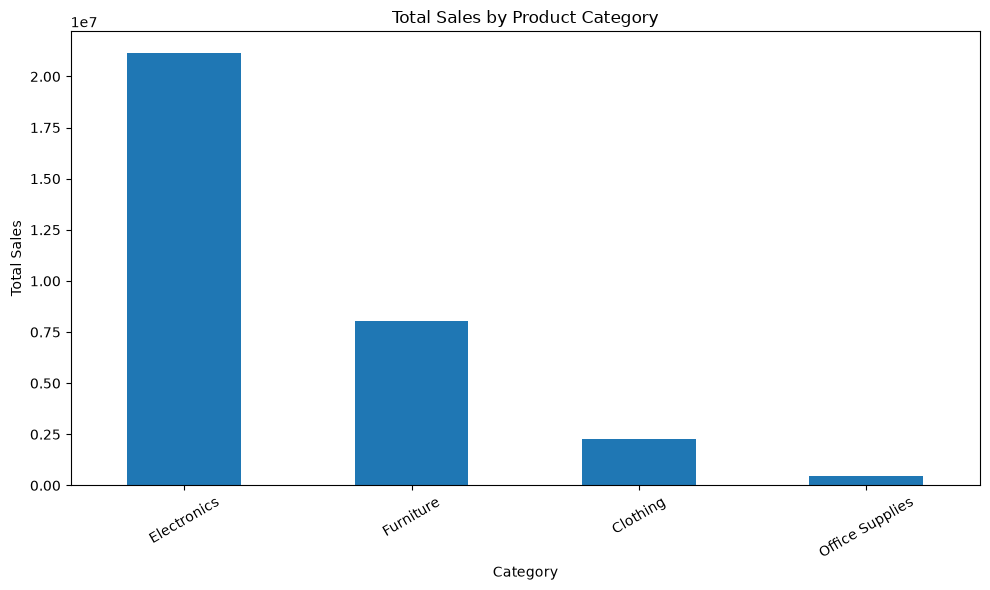

In [14]:
category_sales = df.groupby("Category")["Sales"].sum()
category_sales = category_sales.sort_values(
    ascending=False)
print(category_sales)
plt.figure(figsize=(10, 6))
category_sales.plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Month
2025-01    2408009.15
2025-02    2757180.53
2025-03    3200572.99
2025-04    2150543.16
2025-05    2721979.87
2025-06    2812695.88
2025-07    2968651.17
2025-08    2723901.09
2025-09    2932473.34
2025-10    2177896.08
2025-11    2607104.23
2025-12    2479495.85
Name: Sales, dtype: float64


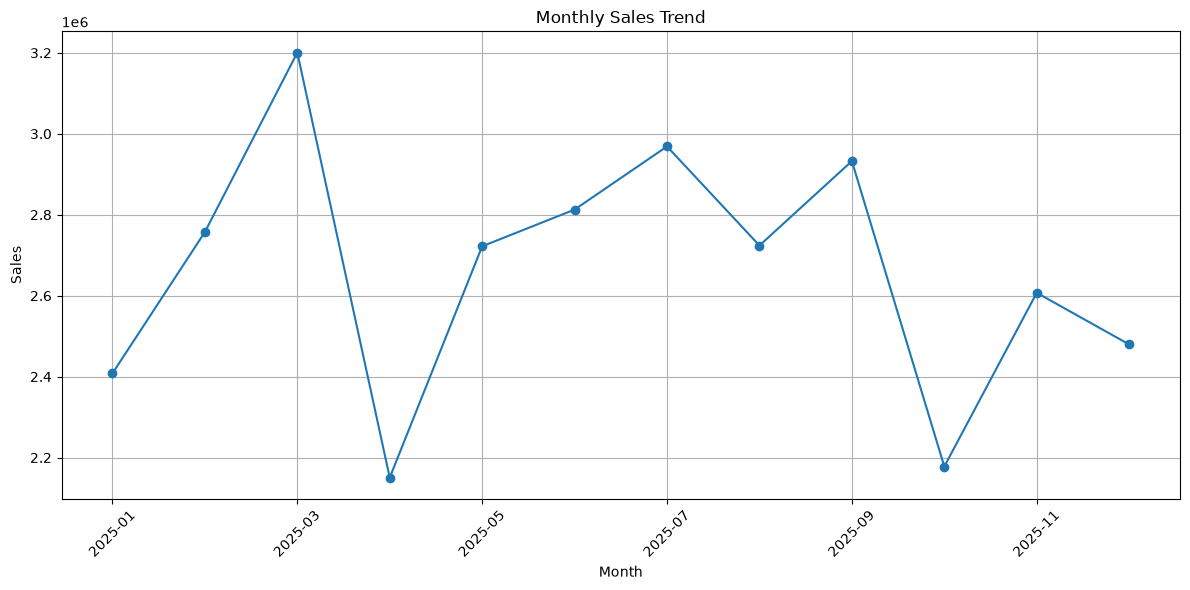

In [15]:
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)
plt.figure(figsize=(12, 6))
monthly_sales.plot(
    kind="line",
    marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Product
Monitor         6427965.86
Laptop          6063866.71
Headphones      5438136.70
Keyboard        3219924.17
Bookshelf       2317162.88
Table           2303427.13
Desk            1973390.00
Office Chair    1461843.70
Jeans            769387.27
T-Shirt          674251.62
Name: Sales, dtype: float64


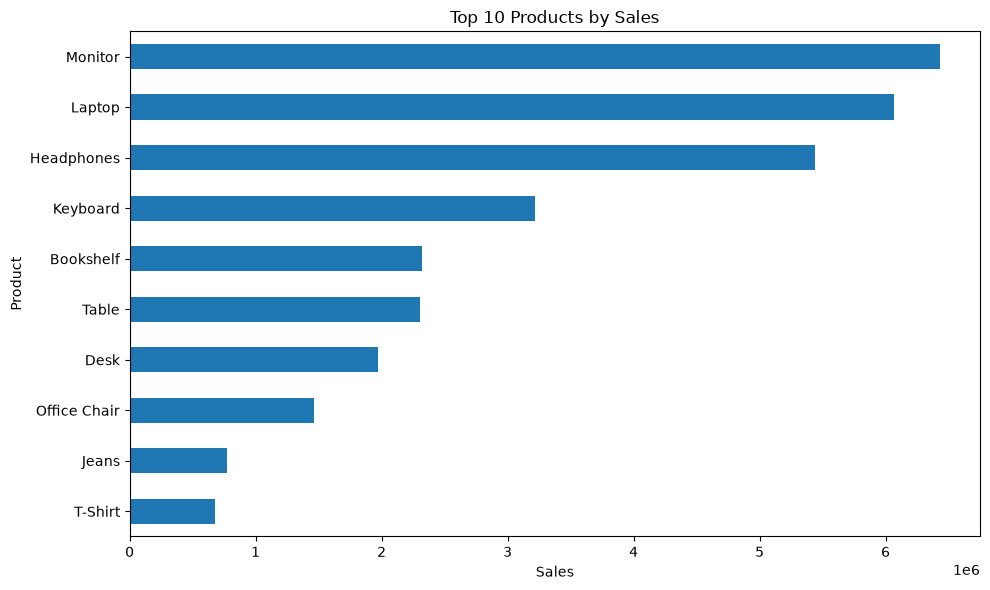

In [16]:
top_products = ( df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10))
print(top_products)
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(
    kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


H0: Quantity sold and Sales are not linearly related.
H1: Quantity sold and Sales have a positive
relationship.

Correlation between Quantity and Sales: 0.327


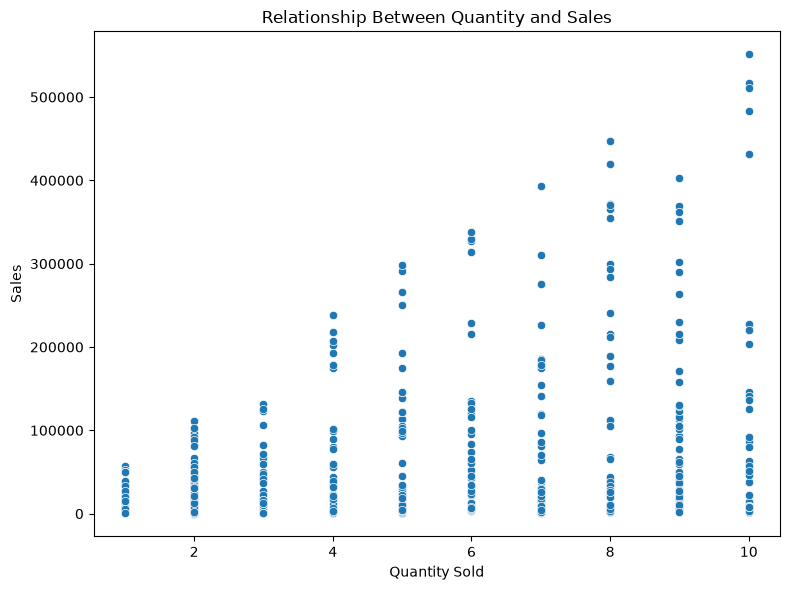

In [17]:
print("""
H0: Quantity sold and Sales are not linearly related.
H1: Quantity sold and Sales have a positive
relationship.
""")
correlation = df["Quantity"].corr(df["Sales"])
print(
    "Correlation between Quantity and Sales:",
    round(correlation, 3))
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales")
plt.title("Relationship Between Quantity and Sales")
plt.xlabel("Quantity Sold")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [18]:
if correlation > 0:
    print("Result: Positive relationship exists between Quantity and Sales.")

elif correlation < 0:
    print("Result: Negative relationship exists between Quantity and Sales.")

else:
    print("Result: No linear relationship found.")

Result: Positive relationship exists between Quantity and Sales.


In [19]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = df[
    (df["Sales"] < lower_limit) |
    (df["Sales"] > upper_limit)]
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))

Q1: 6889.83
Q3: 78233.3
IQR: 71343.47
Lower Limit: -100125.375
Upper Limit: 185248.505
Number of Outliers: 54


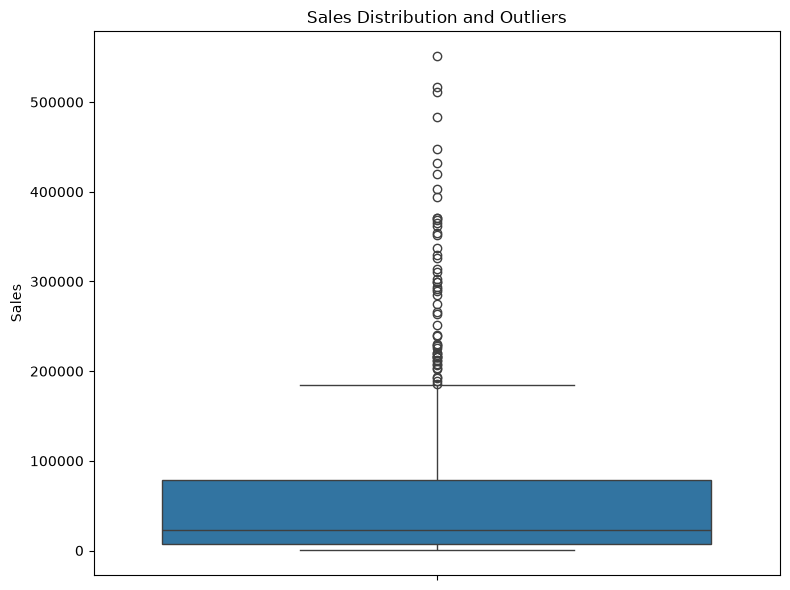

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df["Sales"])
plt.title("Sales Distribution and Outliers")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [23]:
correlation_matrix = df[
    ["Quantity", "Unit_Price", "Sales"]
].corr()

correlation_matrix

,Quantity,Unit_Price,Sales
Quantity,1.000000,-0.053017,0.326927
Unit_Price,-0.053017,1.000000,0.814286
Sales,0.326927,0.814286,1.000000


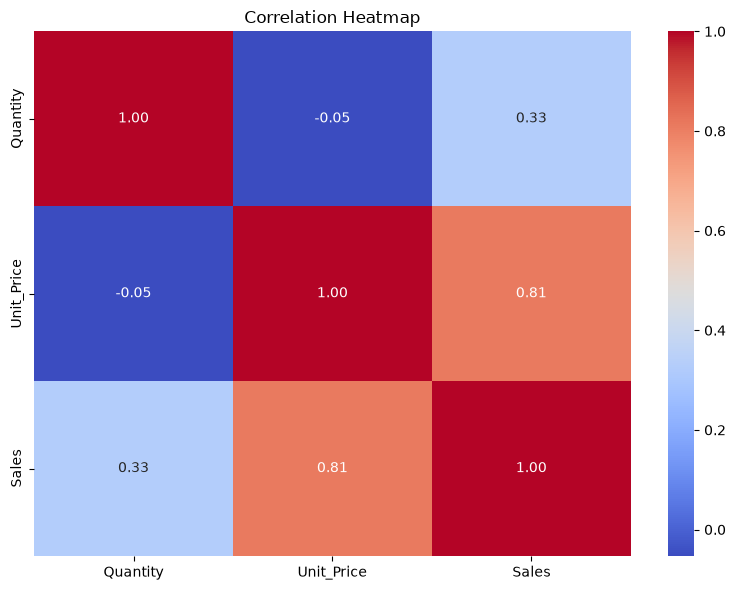

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [26]:
highest_category = category_sales.idxmax()
highest_month = monthly_sales.idxmax()
top_product = top_products.idxmax()
print("KEY FINDINGS")
print(
    "1. Highest-selling category:",
    highest_category)
print(
    "2. Highest-sales month:",
    highest_month)
print(
    "3. Top-selling product:",
    top_product)
print(
    "4. Quantity-Sales correlation:",
    round(correlation, 3))
print(
    "5. Number of sales outliers:",
    len(outliers))

KEY FINDINGS
1. Highest-selling category: Electronics
2. Highest-sales month: 2025-03
3. Top-selling product: Monitor
4. Quantity-Sales correlation: 0.327
5. Number of sales outliers: 54


**CONCLUSION** 

The Exploratory Data Analysis helped us understand
the retail sales dataset.

**The analysis identified:**

• Highest-performing product category 

• Monthly sales trends

• Top-selling products 

• Relationship between quantity and sales 

• Missing values and duplicate records

• Potential sales outliers

The visualizations helped me to understand the important
patterns and trends in the retail data.
These insights can be useful for inventory planning,
sales strategy, business decision-making and future
machine learning or predictive analysis.